# Model error drift (e3sm_diags PCC/RMSE) — Full-CPL

Figures:
* `Full-CPL_SEAS4_global_PCC.pdf`
* `Full-CPL_SEAS4_global_RMSE_ratio_percent.pdf`

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

import os
import re
import glob
import string
import json
import numpy as np
import xarray as xr
import cftime
import fnmatch
import pandas as pd
import seaborn as sns
from collections import OrderedDict
from scipy.stats import linregress

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, FixedLocator
from matplotlib.colors import TwoSlopeNorm, BoundaryNorm,ListedColormap
import matplotlib as mpl
from matplotlib.patches import Polygon, Patch, Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable

from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish
from util.model_error import SpinupMetricAnalyzer

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/model_error_drift"
DATA_DIR     = f"{OUTPUT_ROOT}/data/model_error_drift"     # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPERIMENT     = "Full-CPL"    # experiment analysed (spin-up followed by its piControl)


In [3]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_drift
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_drift


## 1 Seasonal PCC/RMSE metrics

[INFO] windows: first spin-up=0001-0050, first piControl=2001-2050, last=2451-2500
[INFO] Catalog filter: matched rows=68, matched base vars=68
[INFO] Loaded metrics for 68 variables (all selected).
[INFO] Collapsed per metric: kept 68 base variables with per-metric best obs.
[INFO] RMSE: 1 variables have no finite values across periods: AODDUST
[INFO] Bias: 1 variables have no finite values across periods: AODDUST
[INFO] PCC: 1 variables have no finite values across periods: AODDUST


/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:565: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:565: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:565: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)


[INFO] Wrote diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/model_error/Full-CPL_spinup_diagnostics_DJF_global.nc
[INFO] Loaded diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/model_error/Full-CPL_spinup_diagnostics_DJF_global.nc

[=== Dataset Diagnostic Summary ===]
Experiment: 20231209.v3.LR.piControl-spinup.chrysalis vs v3.LR.piControl
Season:     DJF
Reference:  window-mean over 2001-2500
Periods:    50 (0001-0050 → 2451-2500)
Variables:  68
Metrics:    ['Bias', 'RMSE', 'PCC', 'Bias_sigma_obs', 'RMSE_sigma_obs', 'Bias_delta_obs', 'RMSE_delta_obs', 'Bias_ratio_ref', 'RMSE_ratio_ref', 'Bias_rel_ref', 'RMSE_rel_ref', 'Bias_delta_sigma', 'RMSE_delta_sigma']
---------------------------------------
Bias            min= -31.933  max=   6.051  finite= 0.99
RMSE            min=   0.026  max=  55.221  finite= 0.99
PCC             min=   0.448  max=   1.000  finite= 0.99

[INFO] windows: f

/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:565: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:565: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:565: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)


[INFO] windows: first spin-up=0001-0050, first piControl=2001-2050, last=2451-2500
[INFO] Catalog filter: matched rows=68, matched base vars=68
[INFO] Loaded metrics for 68 variables (all selected).
[INFO] Collapsed per metric: kept 68 base variables with per-metric best obs.
[INFO] RMSE: 1 variables have no finite values across periods: AODDUST
[INFO] Bias: 1 variables have no finite values across periods: AODDUST
[INFO] PCC: 1 variables have no finite values across periods: AODDUST
[INFO] Wrote diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/model_error/Full-CPL_spinup_diagnostics_JJA_global.nc
[INFO] Loaded diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/model_error/Full-CPL_spinup_diagnostics_JJA_global.nc

[=== Dataset Diagnostic Summary ===]
Experiment: 20231209.v3.LR.piControl-spinup.chrysalis vs v3.LR.piControl
Season:     JJA
Reference:  window-mean over 2001-2500
Periods:  

/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:565: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:565: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:565: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)


[INFO] windows: first spin-up=0001-0050, first piControl=2001-2050, last=2451-2500
[INFO] Catalog filter: matched rows=68, matched base vars=68
[INFO] Loaded metrics for 68 variables (all selected).
[INFO] Collapsed per metric: kept 68 base variables with per-metric best obs.
[INFO] RMSE: 2 variables have no finite values across periods: AODDUST, TGCLDLWP_OCN
[INFO] Bias: 2 variables have no finite values across periods: AODDUST, TGCLDLWP_OCN
[INFO] PCC: 2 variables have no finite values across periods: AODDUST, TGCLDLWP_OCN
[INFO] Wrote diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/model_error/Full-CPL_spinup_diagnostics_SON_global.nc
[INFO] Loaded diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/model_error/Full-CPL_spinup_diagnostics_SON_global.nc

[=== Dataset Diagnostic Summary ===]
Experiment: 20231209.v3.LR.piControl-spinup.chrysalis vs v3.LR.piControl
Season:     SON
Referen

/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:565: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:565: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:565: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)


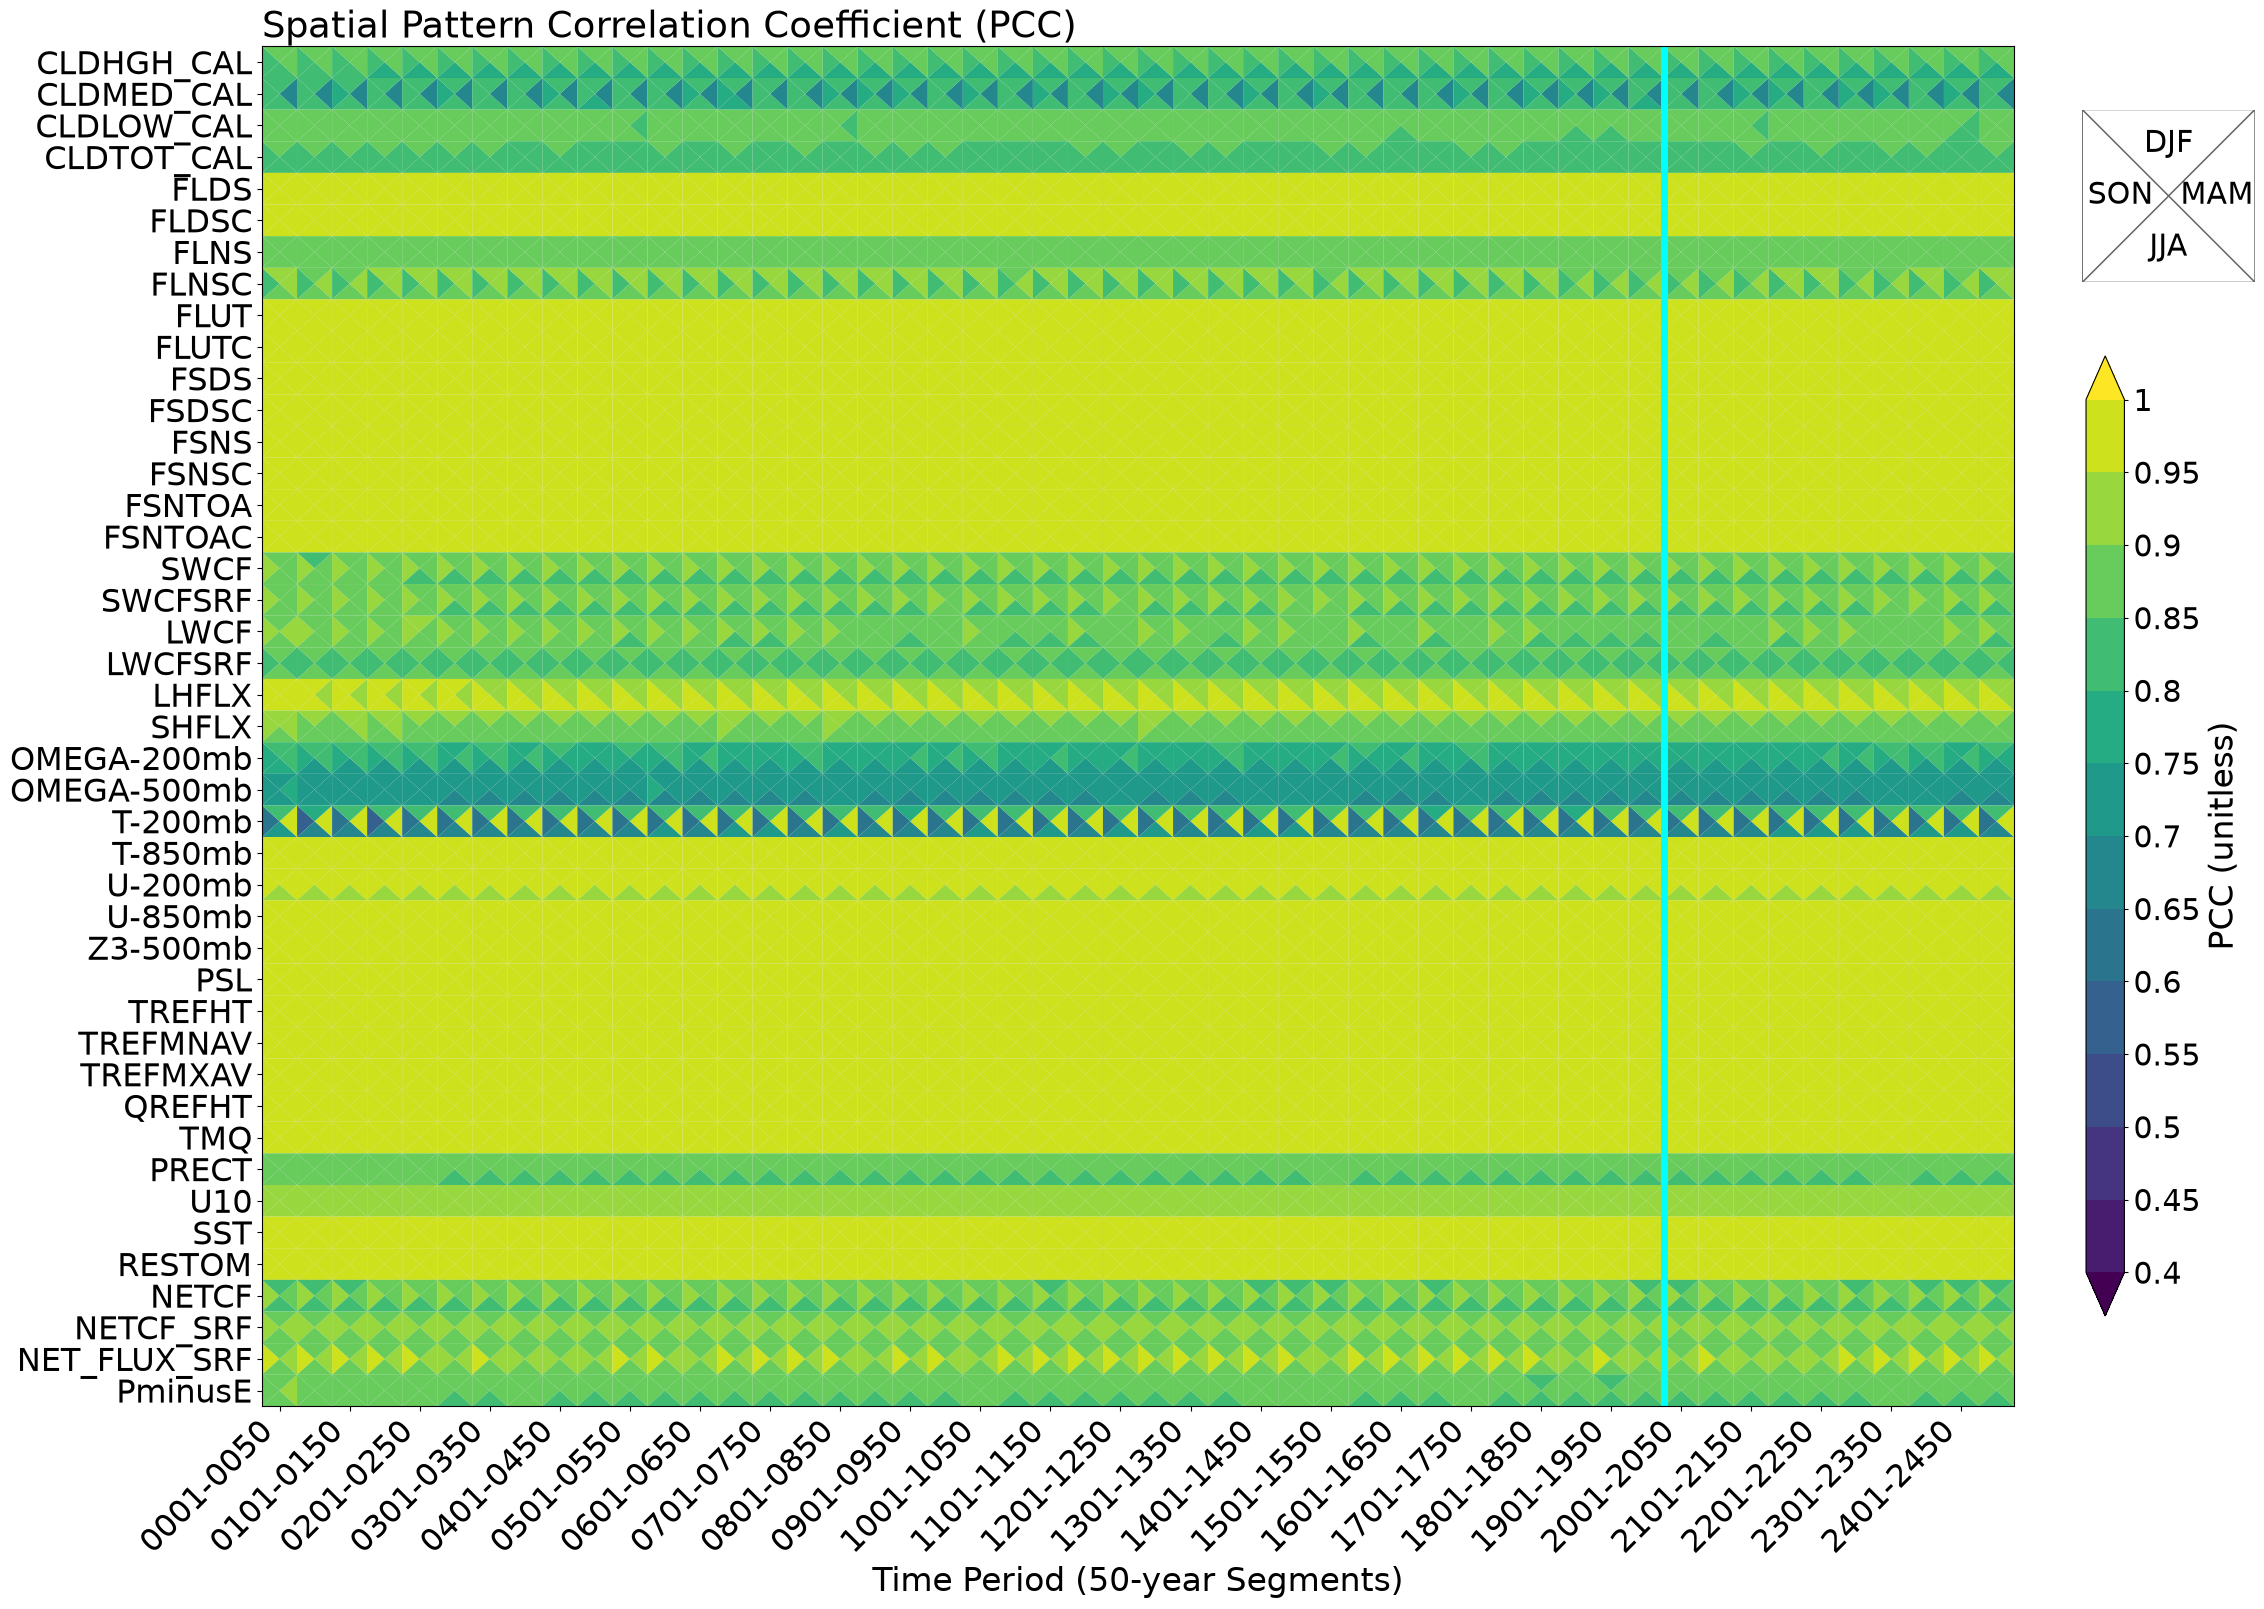

[INFO] Saved figure: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_drift/Full-CPL_SEAS4_global_PCC.pdf


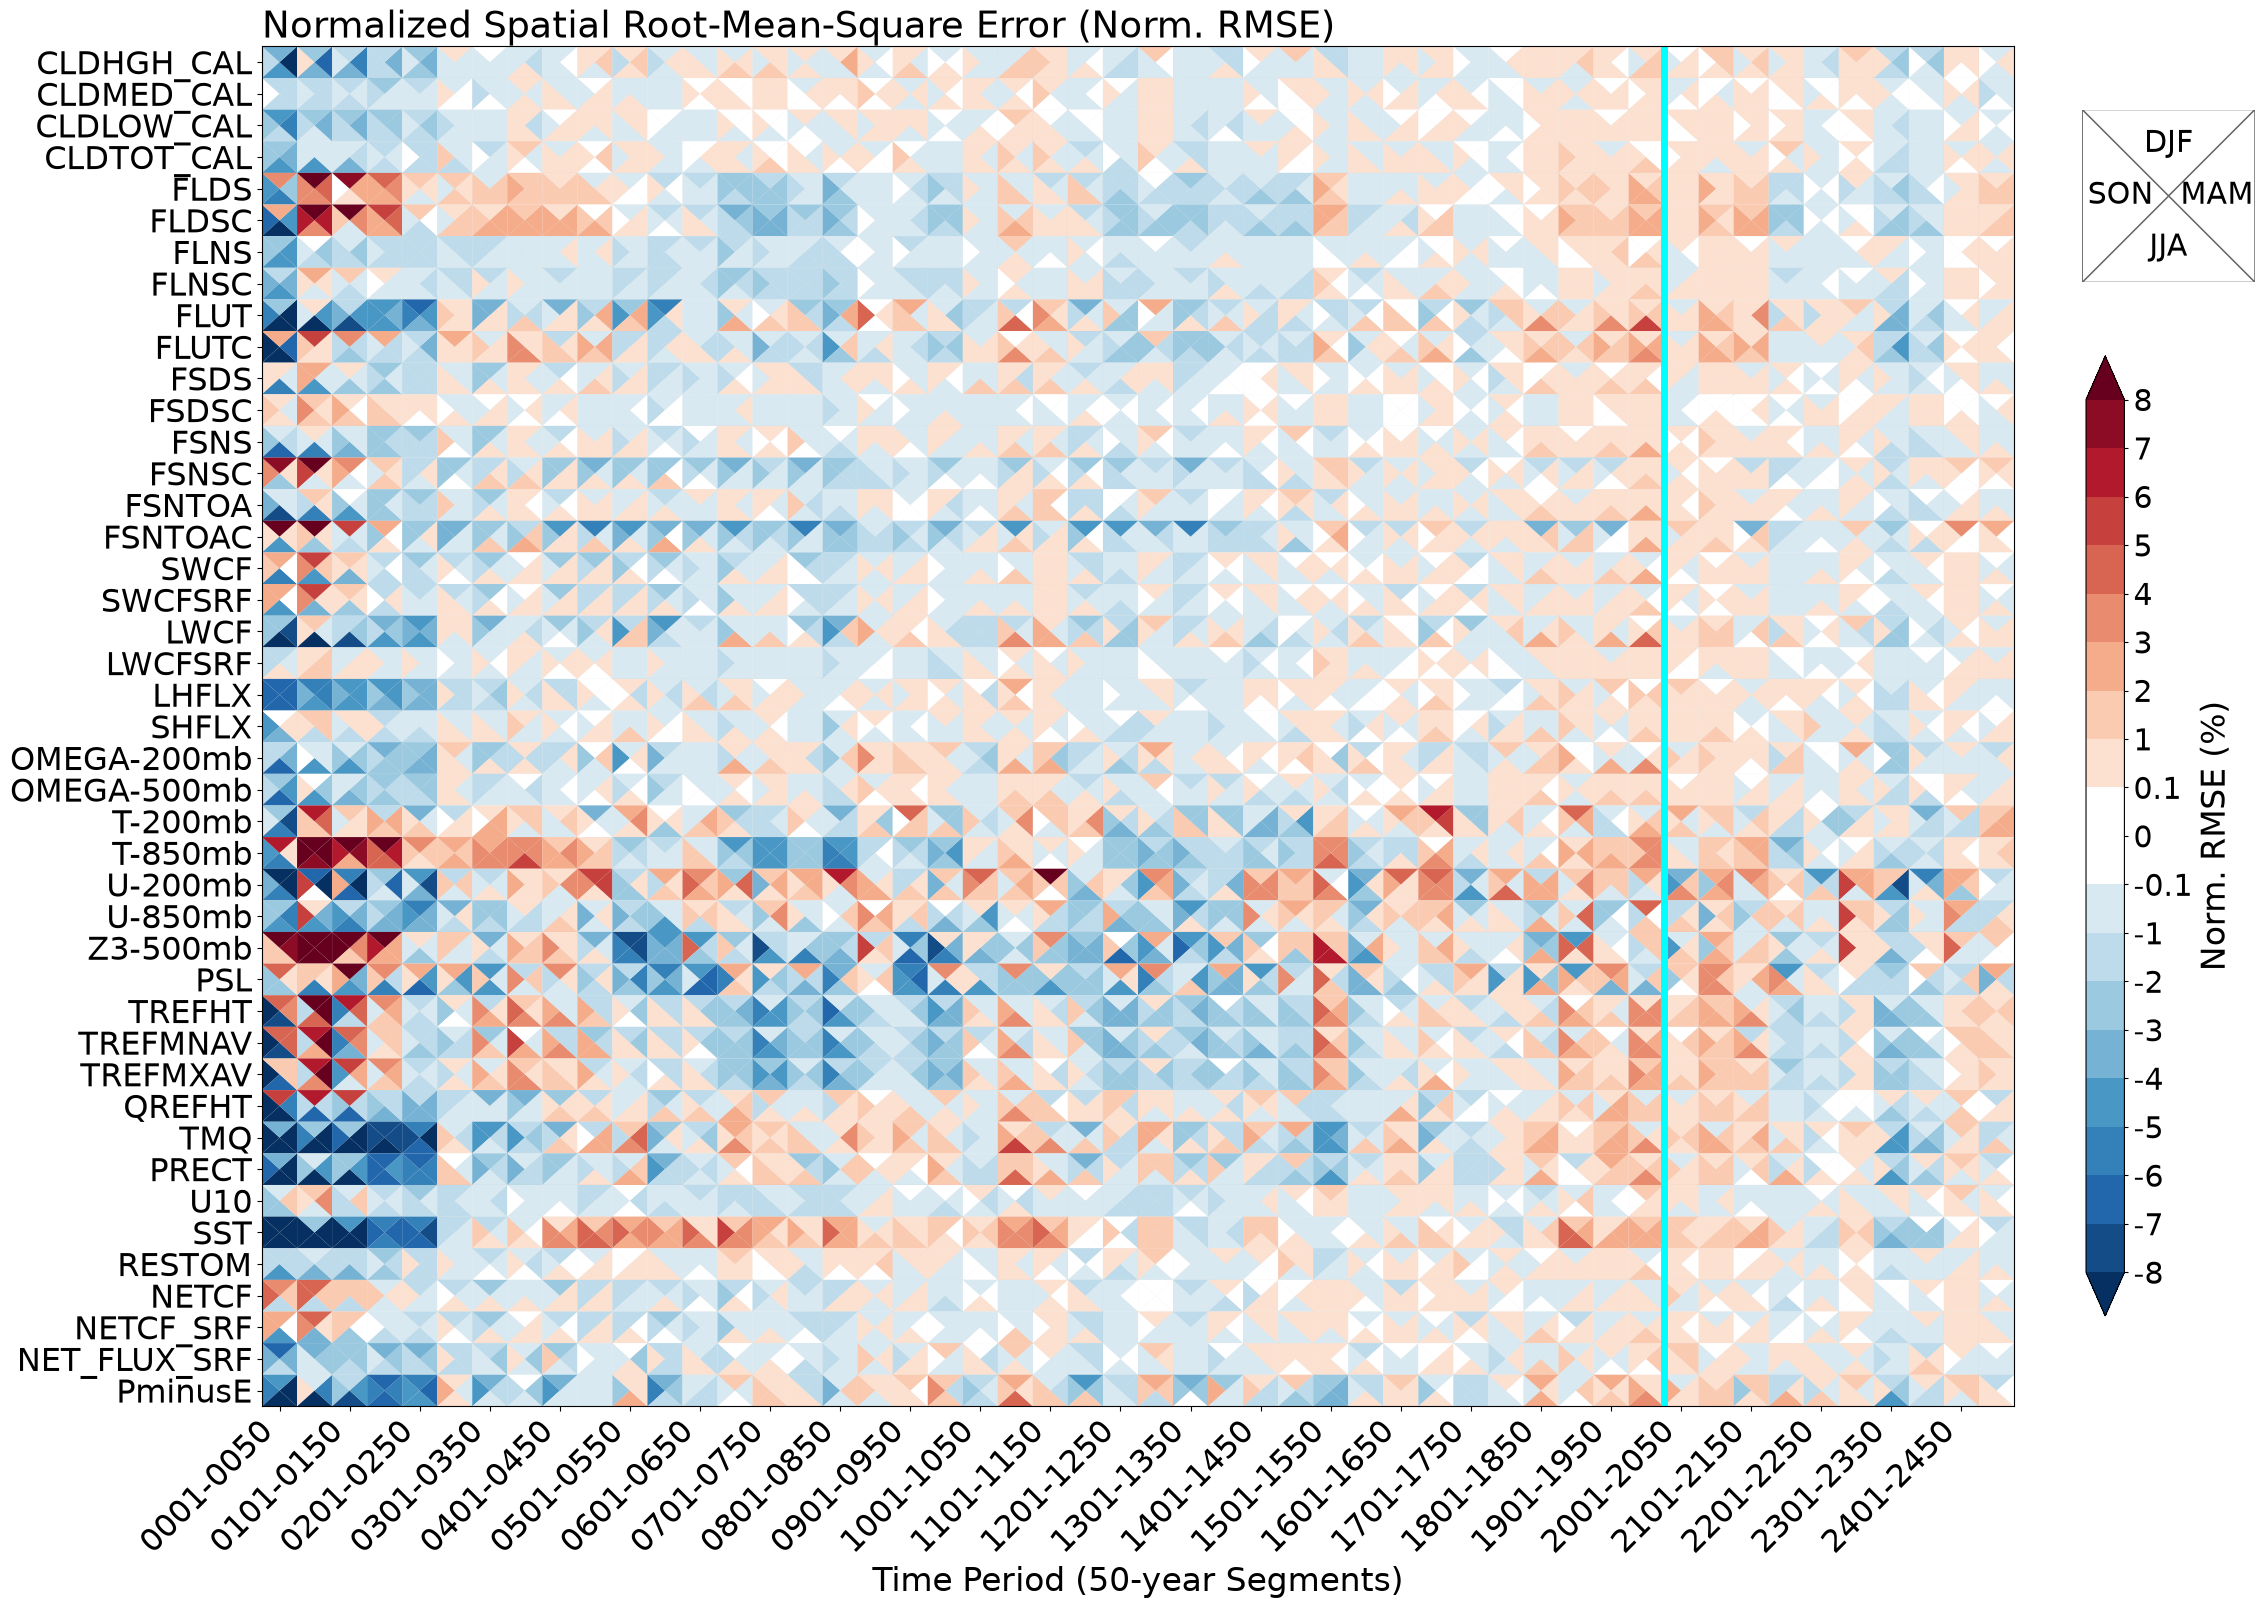

[INFO] Saved figure: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_drift/Full-CPL_SEAS4_global_RMSE_ratio_percent.pdf
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] All plots generated successfully.
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_drift


In [4]:
data_dir    = f"{OUTPUT_ROOT}/data/diag_data"   # e3sm_diags seasonal metrics tables
out_dir     = DATA_DIR
fig_dir     = FIG_DIR
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

experiment     = EXPERIMENT
spinup_name    = run_dict[experiment]["spin-up"]["name"]
picontrol_name = run_dict[experiment]["piControl"]["name"]

# --- Reference: use window mean, not a single period ---
reference_period       = None            # e.g., "2451-2500" if you want single-row ref
reference_window       = (2001, 2500)    # window-mean normalization
spinup_years           = 2500
picontrol_switch_year  = 2000

strategy_map  = {"Mean_Bias": "min_abs", "RMSE": "min", "Correlation": "max"}
obs_priority  = ["GPCP", "CMAP", "ERA5"]
use_ref       = True

fontz         = 24
discrete      = True
dtype         = "float32"

separator_year  = 2000
separator_color = "Cyan"
separator_style = "-"
separator_width = 5.0

seasons = ["DJF", "MAM", "JJA", "SON"]
transpose = True          # NEW: time on x (True) vs y (False)
show_season_box = True      # NEW: add mini season legend (square)
if transpose: 
    figsize       = (24, 16)
    x_step        = 2
    y_step        = 1
    xlabel        = "Time Period (50-year Segments)"
    ylabel        = ""
else:
    figsize       = (16, 24)
    x_step        = 1
    y_step        = 4
    xlabel        = "" 
    ylabel        = "Time Period (50-year Segments)"

# OPTIONAL: lock the exact triplets + display order from your plot dict
plt_dict_file = os.path.join(WF_ROOT, "config", "pltvar_region_sources.json")
use_catalog = os.path.isfile(plt_dict_file)

analyzers_by_season = {}
for s in seasons:
    diag_nc = os.path.join(out_dir, f"{experiment}_spinup_diagnostics_{s}_global.nc")
    an = SpinupMetricAnalyzer(
            bias_ratio_metric="Bias",        # drifting_error definition: bias / ref
        base_dir=data_dir,
        spinup_name=spinup_name,
        picontrol_name=picontrol_name,
        season=s,
        reference_period=reference_period,      # remains None
        reference_window=reference_window,      # window-mean normalization (2001–2500)
        spinup_years=spinup_years,
        picontrol_switch_year=picontrol_switch_year,
    )
    if use_catalog:
        an.use_plot_catalog(plt_dict_file)  # pre-filter + preserve order

    an.extract_metrics()  # reads + (optionally) filters by catalog
    an.set_obs_priority(obs_priority)
    an.collapse_variable_groups_per_metric(strategy_map=strategy_map, use_ref=use_ref)
    an.build_dataset()
    an.to_netcdf(diag_nc, dtype=dtype)
    an.load_dataset(diag_nc)  # reopen for a clean handle
    an.summary()
    analyzers_by_season[s] = an

# ---- Figure out the common variables AFTER all datasets exist ----
vars_by_season = {s: [str(v) for v in an.ds["variable"].values] for s, an in analyzers_by_season.items()}
common = set(vars_by_season[seasons[0]])
for s in seasons[1:]:
    common &= set(vars_by_season[s])

# Preserve a stable order: from the catalog if used, else from DJF’s order
ordered_all = [str(v) for v in analyzers_by_season["DJF"].ds["variable"].values]

vars_to_exclude = [
    "SOLIN","AODDUST","AODVIS","ALBEDO","ALBEDOC","ALBEDO_SRF","TAUXY",
    "TGCLDLWP_OCN","TREF_range","OMEGA-850mb","TCO",
    "*_MODIS","*_MISR","*_ISCCP"
]

vars_to_plot = [
    v for v in ordered_all
    if (
        v in common
        and not any(fnmatch.fnmatch(v, pat) for pat in vars_to_exclude)
    )
]

#print(f"All variables common to all seasons ({len(common)}): {sorted(common)}")
#print(f"Variables to plot in order ({len(vars_to_plot)}): {vars_to_plot}")

# Apply the same ordered selection to every analyzer
for an in analyzers_by_season.values():
    an.select_variables(vars_to_plot)

# ----------------------- Plotting config -----------------------
# For PCC: raw PCC values (mode=None selects "PCC")
# For RMSE: 'ratio' selects RMSE_ratio_ref, which is ((X - Xref)/Xref)*100 (%) in the class
plot_cfg = {
    "Correlation": {
        "mode": None,
        "discrete": True,          # <= continuous scale for PCC
        "bins":np.linspace(0.4, 1, 13),
        "title": "Spatial Pattern Correlation Coefficient (PCC)",
        "cblabel": "PCC (unitless)",
        "outfile": os.path.join(fig_dir, f"{experiment}_SEAS4_global_PCC.pdf"),
    },
    "RMSE": {
        "mode": "ratio",  # <- IMPORTANT: uses RMSE_ratio_ref (% deviation)
        "discrete": True,
        "bins": [-8,-7,-6,-5,-4,-3,-2,-1,-0.1,0,0.1,1,2,3,4,5,6,7,8],  # adjust to taste, e.g. [-50,..,50]
        "title": "Normalized Spatial Root-Mean-Square Error (Norm. RMSE)",
        "cblabel": "Norm. RMSE (%)",
        "outfile": os.path.join(fig_dir, f"{experiment}_SEAS4_global_RMSE_ratio_percent.pdf"),
    },
}

# Pick any analyzer to call the quad-season routine
an_master = analyzers_by_season["DJF"]

# ---------- Plot quad-season ----------
for metric, cfg in plot_cfg.items():
    an_master.plot_heatmap_quadseason(
        analyzers_by_season=analyzers_by_season,
        metric=metric,
        mode=cfg["mode"],
        fig_path=cfg["outfile"],
        discrete=cfg.get("discrete", discrete),   # <— use per-metric
        bins=cfg["bins"],
        fontz=fontz,
        title=cfg["title"],
        xlabel=xlabel,
        ylabel=ylabel,
        cblabel=cfg["cblabel"],
        x_step=x_step,
        y_step=y_step,
        figsize=figsize,
        transpose = transpose,          
        show_season_box = show_season_box,   
        separator_year=separator_year,
        separator_color=separator_color,
        separator_style=separator_style,
        separator_width=separator_width,
    )

for an in analyzers_by_season.values():
    an.close()
print("[INFO] All plots generated successfully.")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))
